# Notebook 04 — H2 to H4 Moderation Models

**Dissertation:** *Beyond Money: Who Responds to Intergenerational Appeals for Sustainable Cooperation?*

This notebook evaluates Hypotheses 2–4 using a three-level mixed-effects linear probability model. The outcome variable is the round-level indicator of green choice behaviour `extract_green_choice`. Random intercepts are estimated for sessions and participants, reflecting decision rounds nested within participants and participants nested within sessions — the same specification used for H1 in Notebook 03.

- **H2**: the positive effect of intergenerational awareness on green choice is stronger for liberal than for conservative participants, relative to participants who did not receive intergenerational awareness.
- **H3**: as H2, moderated by legacy concern instead of ideology (Prolific only — legacy concern was not collected in MTurk).
- **H4**: as H2, moderated by environmental concern instead of ideology (Prolific only).

Treatment enters as a four-level factor with `NIT&NGI` as the reference category, so each contrast is estimated and interpretable on its own terms. The `T.2` contrast (IT only vs. `NIT&NGI`) is the primary test of each hypothesis, since it isolates intergenerational awareness without the green-information/monetary framing present in `IT&GI`.

Each hypothesis is estimated in two forms, following the logic established for H1: a **primary** specification (lean, confirmatory) and a **robustness check** adding the full pre-treatment demographic covariate set (age, gender, education, ethnicity, trust in scientists, and the Prolific-only risk and reward-preference controls). None of `liberal_z`, `legacy_z`, or `env_concern_z` are randomly assigned, so this check guards against demographic confounding of the moderator terms.

H4 additionally carries a **climate-belief robustness check**. The environmental-concern composite `env_concern_z` is a multi-item value-orientation measure; four further single-item climate measures were collected in the Prolific study — climate worry (`environment_worry`), personal responsibility (`environment_responsibility`), belief that the climate is changing (`environment_changing`), and belief that change is a natural rather than human-driven process (`env_natural_process_ctrl`, the climate-denial response coded missing during preparation). These capture climate cognition distinct from the biospheric-value content of the composite. The climate-controls specification augments the primary H4 model with these four measures to establish that any environmental-concern moderation is not an artefact of correlated climate beliefs. The continuous items are z-standardised for scale comparability; `environment_changing` enters as a factor given its small ordered-category structure.


## 1 · Setup


In [1]:
# Cell 1: Imports and global configuration
import warnings
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 100)

os.makedirs('outputs/tables', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)

TREAT_MAP = {1: 'IT&GI', 2: 'IT', 3: 'GI', 4: 'NIT&NGI'}
TREAT_ORDER = ['IT&GI', 'IT', 'GI', 'NIT&NGI']

print('Environment ready.')

import matplotlib.pyplot as plt

os.makedirs('outputs/figures', exist_ok=True)

# Consistent treatment palette across all figures in the project.
TREAT_COLORS = {'IT&GI': '#2196F3', 'IT': '#4CAF50', 'GI': '#FF9800', 'NIT&NGI': '#9E9E9E'}
plt.rcParams.update({'figure.dpi': 150})


Environment ready.


## 2 · Load Analytic Datasets

The inputs are the analytic CSVs written by Notebook 01. No additional row deletion is introduced here.


In [2]:
# Cell 2: Load analytic datasets
mt = pd.read_csv('data/mturk_clean.csv')
pr = pd.read_csv('data/prolific_clean.csv')

def prepare_common_fields(df):
    df = df.copy()
    df['treatment_str'] = df['treatment'].map(TREAT_MAP)
    df['round_c'] = df['round'] - df['round'].mean()
    return df

mt = prepare_common_fields(mt)
pr = prepare_common_fields(pr)

# Z-standardise the continuous single-item climate measures used in the H4
# climate-belief robustness check (Prolific only). environment_changing is
# left on its original scale and enters as a factor in the formula.
CLIMATE_CONTINUOUS = ['environment_worry', 'environment_responsibility', 'env_natural_process_ctrl']
for col in CLIMATE_CONTINUOUS:
    if col in pr.columns:
        pr[f'{col}_z'] = (pr[col] - pr[col].mean()) / pr[col].std(ddof=1)

print(f"MTurk: {len(mt):,} rows | {mt['participantcode'].nunique():,} participants | {mt['sessioncode'].nunique():,} sessions")
print(f"Prolific: {len(pr):,} rows | {pr['participantcode'].nunique():,} participants | {pr['sessioncode'].nunique():,} sessions")

# env_natural_process_ctrl carries missing values by design (climate-denial
# response set to NaN in preparation); report the resulting analytic-N impact
# for the climate-controls specification, which listwise-drops those rows.
n_missing_npc = pr['env_natural_process_ctrl'].isna().sum() if 'env_natural_process_ctrl' in pr.columns else 0
n_part_npc = pr.loc[pr['env_natural_process_ctrl'].isna(), 'participantcode'].nunique() if n_missing_npc else 0
print(f"env_natural_process_ctrl missing: {n_missing_npc:,} rows across {n_part_npc} participants "
      f"(climate-denial responses; excluded from the H4 climate-controls model only)")


MTurk: 10,220 rows | 1,022 participants | 308 sessions
Prolific: 10,170 rows | 1,017 participants | 288 sessions
env_natural_process_ctrl missing: 80 rows across 8 participants (climate-denial responses; excluded from the H4 climate-controls model only)


In [3]:
# Cell 3: Shared helpers for model estimation, extraction, and export
import patsy


def fit_lpm_mixedlm(df, formula, reml=True):
    """
    Three-level mixed-effects linear probability model:

    Level 1: decision rounds
    Level 2: participants
    Level 3: sessions

    Rows with missing values in formula variables are dropped 
    before estimation to ensure a consistent sample and avoid 
    grouping-related indexing errors.
    """
    _, design = patsy.dmatrices(formula, df, return_type='dataframe', NA_action='drop')
    fit_df = df.loc[design.index].dropna(subset=['sessioncode', 'participantcode'])
    model = MixedLM.from_formula(
        formula=formula,
        groups='sessioncode',
        re_formula='1',
        vc_formula={'participant': '0 + C(participantcode)'},
        data=fit_df
    )
    result = model.fit(reml=reml, method=['lbfgs', 'bfgs', 'cg', 'powell', 'nm'], maxiter=2000, disp=False)
    if not result.converged:
        print('WARNING: model did not converge with any optimizer in the retry sequence.')
    return result


def model_table(result, model_name, study_label):
    """
    Fixed-effect coefficients, standard errors, test statistics, p-values,
    and confidence intervals. Variance components are reported separately by
    variance_table.
    """
    k_fe = result.model.k_fe
    ci = result.conf_int()
    return pd.DataFrame({
        'term': result.params.index[:k_fe],
        'coef': result.params.values[:k_fe],
        'se': result.bse.values[:k_fe],
        'z': result.tvalues.values[:k_fe],
        'p': result.pvalues.values[:k_fe],
        'ci_low': ci[0].values[:k_fe],
        'ci_high': ci[1].values[:k_fe],
        'model': model_name,
        'study': study_label,
    })


def variance_table(result, model_name, study_label):
    rows = []
    if hasattr(result, 'cov_re') and result.cov_re is not None:
        try:
            rows.append({'component': 'session_intercept_var', 'value': float(np.asarray(result.cov_re)[0, 0])})
        except Exception:
            pass
    if hasattr(result, 'vcomp') and result.vcomp is not None:
        vals = np.atleast_1d(result.vcomp)
        for i, v in enumerate(vals, start=1):
            label = 'participant_intercept_var' if i == 1 else f'vc_formula_component_{i}'
            rows.append({'component': label, 'value': float(v)})
    rows.append({'component': 'residual_scale', 'value': float(result.scale)})
    out = pd.DataFrame(rows)
    out['model'] = model_name
    out['study'] = study_label
    return out


def fit_and_export(df, formula, model_name, study_label, prefix):
    result = fit_lpm_mixedlm(df, formula)
    coef_tbl = model_table(result, model_name, study_label)
    var_tbl = variance_table(result, model_name, study_label)
    slug = study_label.lower().replace(' ', '_').replace('(', '').replace(')', '')
    coef_tbl.to_csv(f'outputs/tables/{prefix}_{slug}_coefficients.csv', index=False)
    var_tbl.to_csv(f'outputs/tables/{prefix}_{slug}_variance_components.csv', index=False)
    with open(f'outputs/models/{prefix}_{slug}_summary.txt', 'w') as f:
        f.write(result.summary().as_text())
    return result, coef_tbl, var_tbl


## 3 · Moderation Specifications

Treatment enters directly as the four-level factorial assignment, interacted with each hypothesis's focal moderator:

`extract_green_choice ~ C(treatment, Treatment(reference=4)) * moderator + round_c`

The focal moderation terms are the interaction coefficients between each treatment contrast and the moderator. The `T.2` (IT-only) interaction is the cleanest test of each hypothesis, since it isolates intergenerational awareness from the green-information/monetary framing present in `IT&GI`.

Each hypothesis is estimated in two forms, following the same logic established for H1: a **primary** specification (lean, confirmatory) and a **robustness check** adding the full demographic covariate set, since none of the three moderators are randomly assigned.


In [4]:
# Cell 3: Model formulas for H2–H4 (primary and robustness-check specifications)
H2_FORMULA_PRIMARY = 'extract_green_choice ~ C(treatment, Treatment(reference=4)) * liberal_z + round_c'
H2_FORMULA_ROBUST_MT = (
    'extract_green_choice ~ C(treatment, Treatment(reference=4)) * liberal_z + round_c + '
    'age + C(gender) + C(education) + C(ethnic_min) + trust_scientists_z'
)
H2_FORMULA_ROBUST_PR = (
    'extract_green_choice ~ C(treatment, Treatment(reference=4)) * liberal_z + round_c + '
    'age + C(gender) + C(education) + C(ethnic_min) + trust_scientists_z + '
    'risk_attitude_z + short_long_reward_z'
)

H3_FORMULA_PRIMARY = 'extract_green_choice ~ C(treatment, Treatment(reference=4)) * legacy_z + round_c'
H3_FORMULA_ROBUST_PR = (
    'extract_green_choice ~ C(treatment, Treatment(reference=4)) * legacy_z + round_c + '
    'age + C(gender) + C(education) + C(ethnic_min) + trust_scientists_z + '
    'risk_attitude_z + short_long_reward_z'
)

H4_FORMULA_PRIMARY = 'extract_green_choice ~ C(treatment, Treatment(reference=4)) * env_concern_z + round_c'
H4_FORMULA_ROBUST_PR = (
    'extract_green_choice ~ C(treatment, Treatment(reference=4)) * env_concern_z + round_c + '
    'age + C(gender) + C(education) + C(ethnic_min) + trust_scientists_z + '
    'risk_attitude_z + short_long_reward_z'
)
# H4 climate-belief robustness: primary H4 augmented with the four single-item
# climate measures, isolating the env_concern_z moderation from correlated
# climate cognition.
H4_FORMULA_CLIMATE_PR = (
    'extract_green_choice ~ C(treatment, Treatment(reference=4)) * env_concern_z + round_c + '
    'environment_worry_z + environment_responsibility_z + '
    'C(environment_changing) + env_natural_process_ctrl_z'
)

print('H2 primary formula (both studies):')
print(H2_FORMULA_PRIMARY)
print('\nH2 full-controls robustness formula (MTurk):')
print(H2_FORMULA_ROBUST_MT)
print('\nH2 full-controls robustness formula (Prolific):')
print(H2_FORMULA_ROBUST_PR)
print('\nH3 primary formula (Prolific):')
print(H3_FORMULA_PRIMARY)
print('\nH3 full-controls robustness formula (Prolific):')
print(H3_FORMULA_ROBUST_PR)
print('\nH4 primary formula (Prolific):')
print(H4_FORMULA_PRIMARY)
print('\nH4 full-controls robustness formula (Prolific):')
print(H4_FORMULA_ROBUST_PR)
print('\nH4 climate-belief robustness formula (Prolific):')
print(H4_FORMULA_CLIMATE_PR)

H2 primary formula (both studies):
extract_green_choice ~ C(treatment, Treatment(reference=4)) * liberal_z + round_c

H2 full-controls robustness formula (MTurk):
extract_green_choice ~ C(treatment, Treatment(reference=4)) * liberal_z + round_c + age + C(gender) + C(education) + C(ethnic_min) + trust_scientists_z

H2 full-controls robustness formula (Prolific):
extract_green_choice ~ C(treatment, Treatment(reference=4)) * liberal_z + round_c + age + C(gender) + C(education) + C(ethnic_min) + trust_scientists_z + risk_attitude_z + short_long_reward_z

H3 primary formula (Prolific):
extract_green_choice ~ C(treatment, Treatment(reference=4)) * legacy_z + round_c

H3 full-controls robustness formula (Prolific):
extract_green_choice ~ C(treatment, Treatment(reference=4)) * legacy_z + round_c + age + C(gender) + C(education) + C(ethnic_min) + trust_scientists_z + risk_attitude_z + short_long_reward_z

H4 primary formula (Prolific):
extract_green_choice ~ C(treatment, Treatment(reference=4))

## 4 · H2 — Political Ideology as Moderator

Both studies. Primary specification first, then the robustness check with full covariate adjustment.


In [5]:
# Cell 4: H2 estimation in both studies (primary and robustness-check)
res_h2_mt, coef_h2_mt, var_h2_mt = fit_and_export(
    mt, H2_FORMULA_PRIMARY, model_name='H2 primary', study_label='Study 1 (MTurk)', prefix='h2'
)
res_h2_pr, coef_h2_pr, var_h2_pr = fit_and_export(
    pr, H2_FORMULA_PRIMARY, model_name='H2 primary', study_label='Study 2 (Prolific)', prefix='h2'
)

print('=== Study 1 (MTurk) - H2 Primary ===')
print(res_h2_mt.summary())
print()
print('=== Study 2 (Prolific) - H2 Primary ===')
print(res_h2_pr.summary())

res_h2_mt_robust, coef_h2_mt_robust, var_h2_mt_robust = fit_and_export(
    mt, H2_FORMULA_ROBUST_MT, model_name='H2 robustness (full controls)', study_label='Study 1 (MTurk)', prefix='h2_robust'
)
res_h2_pr_robust, coef_h2_pr_robust, var_h2_pr_robust = fit_and_export(
    pr, H2_FORMULA_ROBUST_PR, model_name='H2 robustness (full controls)', study_label='Study 2 (Prolific)', prefix='h2_robust'
)

print()
print('=== Study 1 (MTurk) - H2 Robustness check ===')
print(res_h2_mt_robust.summary())
print()
print('=== Study 2 (Prolific) - H2 Robustness check ===')
print(res_h2_pr_robust.summary())


=== Study 1 (MTurk) - H2 Primary ===
                            Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          extract_green_choice
No. Observations:           10220            Method:                      REML                
No. Groups:                 308              Scale:                       0.1461              
Min. group size:            10               Log-Likelihood:              -5386.1416          
Max. group size:            40               Converged:                   Yes                 
Mean group size:            33.2                                                              
----------------------------------------------------------------------------------------------
                                                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------------
Intercept                                 

## 5 · H3 — Legacy Concern as Moderator (Prolific)

Legacy concern was collected in Prolific only. Primary specification first, then the robustness check.


In [6]:
# Cell 5: H3 estimation in Prolific only (primary and robustness-check)
res_h3_pr, coef_h3_pr, var_h3_pr = fit_and_export(
    pr, H3_FORMULA_PRIMARY, model_name='H3 primary', study_label='Study 2 (Prolific)', prefix='h3'
)
print('=== Study 2 (Prolific) - H3 Primary ===')
print(res_h3_pr.summary())

res_h3_pr_robust, coef_h3_pr_robust, var_h3_pr_robust = fit_and_export(
    pr, H3_FORMULA_ROBUST_PR, model_name='H3 robustness (full controls)', study_label='Study 2 (Prolific)', prefix='h3_robust'
)
print()
print('=== Study 2 (Prolific) - H3 Robustness check ===')
print(res_h3_pr_robust.summary())


=== Study 2 (Prolific) - H3 Primary ===
                            Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          extract_green_choice
No. Observations:          10170            Method:                      REML                
No. Groups:                288              Scale:                       0.1561              
Min. group size:           10               Log-Likelihood:              -5718.3113          
Max. group size:           40               Converged:                   Yes                 
Mean group size:           35.3                                                              
---------------------------------------------------------------------------------------------
                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                       

## 6 · H4 — Environmental Concern as Moderator (Prolific)

Environmental concern was collected in Prolific only. Three specifications are estimated: the primary model, the full-demographic-controls robustness check, and a climate-belief robustness check augmenting the primary model with the four single-item climate measures. The climate-belief check listwise-drops the small number of climate-denial responses coded missing in preparation, so its analytic N is marginally lower than the other two.


In [7]:
# Cell 6: H4 estimation in Prolific only (primary, full-controls, and climate-belief robustness)
res_h4_pr, coef_h4_pr, var_h4_pr = fit_and_export(
    pr, H4_FORMULA_PRIMARY, model_name='H4 primary', study_label='Study 2 (Prolific)', prefix='h4'
)
print('=== Study 2 (Prolific) - H4 Primary ===')
print(res_h4_pr.summary())

res_h4_pr_robust, coef_h4_pr_robust, var_h4_pr_robust = fit_and_export(
    pr, H4_FORMULA_ROBUST_PR, model_name='H4 robustness (full controls)', study_label='Study 2 (Prolific)', prefix='h4_robust'
)
print()
print('=== Study 2 (Prolific) - H4 Robustness check (full demographic controls) ===')
print(res_h4_pr_robust.summary())

res_h4_pr_climate, coef_h4_pr_climate, var_h4_pr_climate = fit_and_export(
    pr, H4_FORMULA_CLIMATE_PR, model_name='H4 robustness (climate beliefs)', study_label='Study 2 (Prolific)', prefix='h4_climate'
)
print()
print('=== Study 2 (Prolific) - H4 Robustness check (climate-belief controls) ===')
print(res_h4_pr_climate.summary())


=== Study 2 (Prolific) - H4 Primary ===
                              Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           extract_green_choice
No. Observations:             10170             Method:                       REML                
No. Groups:                   288               Scale:                        0.1561              
Min. group size:              10                Log-Likelihood:               -5717.6434          
Max. group size:              40                Converged:                    Yes                 
Mean group size:              35.3                                                                
--------------------------------------------------------------------------------------------------
                                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------------
I

## 7 · Focal Interaction Terms and Sensitivity Comparison

For each hypothesis, the focal inferential targets are the interaction coefficients between the moderator and the treatment contrasts; `T.2` (IT only) is the cleanest test of intergenerational awareness in isolation. The comparison table places primary and robustness-check estimates for these terms side by side, so any sensitivity to the added demographic covariates is visible directly.


In [8]:
# Cell 7: Extract focal moderation terms and build sensitivity comparison
FOCAL_MAP = {
    'H2': ['liberal_z',
           'C(treatment, Treatment(reference=4))[T.1]:liberal_z',
           'C(treatment, Treatment(reference=4))[T.2]:liberal_z',
           'C(treatment, Treatment(reference=4))[T.3]:liberal_z'],
    'H3': ['legacy_z',
           'C(treatment, Treatment(reference=4))[T.1]:legacy_z',
           'C(treatment, Treatment(reference=4))[T.2]:legacy_z',
           'C(treatment, Treatment(reference=4))[T.3]:legacy_z'],
    'H4': ['env_concern_z',
           'C(treatment, Treatment(reference=4))[T.1]:env_concern_z',
           'C(treatment, Treatment(reference=4))[T.2]:env_concern_z',
           'C(treatment, Treatment(reference=4))[T.3]:env_concern_z'],
}

for label, tbl, key in [
    ('H2 — Study 1 (MTurk), Primary', coef_h2_mt, 'H2'),
    ('H2 — Study 2 (Prolific), Primary', coef_h2_pr, 'H2'),
    ('H3 — Study 2 (Prolific), Primary', coef_h3_pr, 'H3'),
    ('H4 — Study 2 (Prolific), Primary', coef_h4_pr, 'H4'),
]:
    print(f'\n{label}')
    print(tbl[tbl['term'].isin(FOCAL_MAP[key])][['term', 'coef', 'se', 'z', 'p', 'ci_low', 'ci_high']].to_string(index=False))

# Primary vs. robustness-check comparison, focal terms only. H4 carries a
# third row set (climate-belief controls) in addition to the full-controls check.
comparison_rows = []
for hyp_key, spec_label, tbl in [
    ('H2', 'Primary', coef_h2_mt), ('H2', 'Robustness (full controls)', coef_h2_mt_robust),
]:
    sub = tbl[tbl['term'].isin(FOCAL_MAP[hyp_key])].copy()
    sub.insert(0, 'hypothesis', hyp_key)
    sub.insert(1, 'spec', spec_label)
    comparison_rows.append(sub)
for hyp_key, spec_label, tbl in [
    ('H2', 'Primary', coef_h2_pr), ('H2', 'Robustness (full controls)', coef_h2_pr_robust),
    ('H3', 'Primary', coef_h3_pr), ('H3', 'Robustness (full controls)', coef_h3_pr_robust),
    ('H4', 'Primary', coef_h4_pr), ('H4', 'Robustness (full controls)', coef_h4_pr_robust),
    ('H4', 'Robustness (climate beliefs)', coef_h4_pr_climate),
]:
    sub = tbl[tbl['term'].isin(FOCAL_MAP[hyp_key])].copy()
    sub.insert(0, 'hypothesis', hyp_key)
    sub.insert(1, 'spec', spec_label)
    comparison_rows.append(sub)

h2h4_comparison = pd.concat(comparison_rows, ignore_index=True)
h2h4_comparison = h2h4_comparison[['study', 'hypothesis', 'spec', 'term', 'coef', 'se', 'z', 'p', 'ci_low', 'ci_high']]
h2h4_comparison.to_csv('outputs/tables/h2_h4_primary_vs_robustness_comparison.csv', index=False)

print('\n\nH2-H4 focal terms: primary vs. robustness-check specifications')
print(h2h4_comparison.to_string(index=False))



H2 — Study 1 (MTurk), Primary
                                               term    coef     se       z      p  ci_low  ci_high
                                          liberal_z  0.0031 0.0139  0.2241 0.8227 -0.0240   0.0303
C(treatment, Treatment(reference=4))[T.1]:liberal_z -0.0232 0.0195 -1.1864 0.2355 -0.0614   0.0151
C(treatment, Treatment(reference=4))[T.2]:liberal_z  0.0011 0.0203  0.0519 0.9586 -0.0387   0.0408
C(treatment, Treatment(reference=4))[T.3]:liberal_z -0.0092 0.0199 -0.4627 0.6436 -0.0483   0.0298

H2 — Study 2 (Prolific), Primary
                                               term    coef     se       z      p  ci_low  ci_high
                                          liberal_z  0.0005 0.0161  0.0334 0.9734 -0.0311   0.0322
C(treatment, Treatment(reference=4))[T.1]:liberal_z -0.0093 0.0219 -0.4260 0.6701 -0.0522   0.0336
C(treatment, Treatment(reference=4))[T.2]:liberal_z -0.0208 0.0231 -0.9007 0.3678 -0.0660   0.0244
C(treatment, Treatment(reference=4))[T.3]:li

## 8 · Consolidated Outputs


In [9]:
# Cell 8: Consolidate all H2–H4 coefficient and variance-component outputs
coef_all = pd.concat([
    coef_h2_mt, coef_h2_pr, coef_h2_mt_robust, coef_h2_pr_robust,
    coef_h3_pr, coef_h3_pr_robust,
    coef_h4_pr, coef_h4_pr_robust, coef_h4_pr_climate,
], ignore_index=True)
var_all = pd.concat([
    var_h2_mt, var_h2_pr, var_h2_mt_robust, var_h2_pr_robust,
    var_h3_pr, var_h3_pr_robust,
    var_h4_pr, var_h4_pr_robust, var_h4_pr_climate,
], ignore_index=True)

coef_all.to_csv('outputs/tables/h2_h4_all_coefficients.csv', index=False)
var_all.to_csv('outputs/tables/h2_h4_all_variance_components.csv', index=False)

print('Exported:')
print(' outputs/tables/h2_h4_all_coefficients.csv')
print(' outputs/tables/h2_h4_all_variance_components.csv')
print(' outputs/tables/h2_h4_primary_vs_robustness_comparison.csv')
print(' outputs/models/h2*, h3*, h4*, h4_climate* summary files')


Exported:
 outputs/tables/h2_h4_all_coefficients.csv
 outputs/tables/h2_h4_all_variance_components.csv
 outputs/tables/h2_h4_primary_vs_robustness_comparison.csv
 outputs/models/h2*, h3*, h4*, h4_climate* summary files


## 9 · Figure — Treatment × Moderator Interactions

The focal quantities for H2–H4 are the interaction coefficients between each treatment contrast and the moderator under test. Reading these from a regression table requires the reader to locate and mentally compare twelve terms across four models; plotting them on a common axis with their confidence intervals renders the pattern immediate.

Each coefficient expresses how much the treatment effect changes per one-standard-deviation increase in the moderator. Under the hypotheses, the intervals for the intergenerational contrasts would lie clearly to one side of zero. The width of each interval carries the additional information that a table of *p*-values cannot: it distinguishes a null arising from imprecision from one arising from a genuinely small effect.

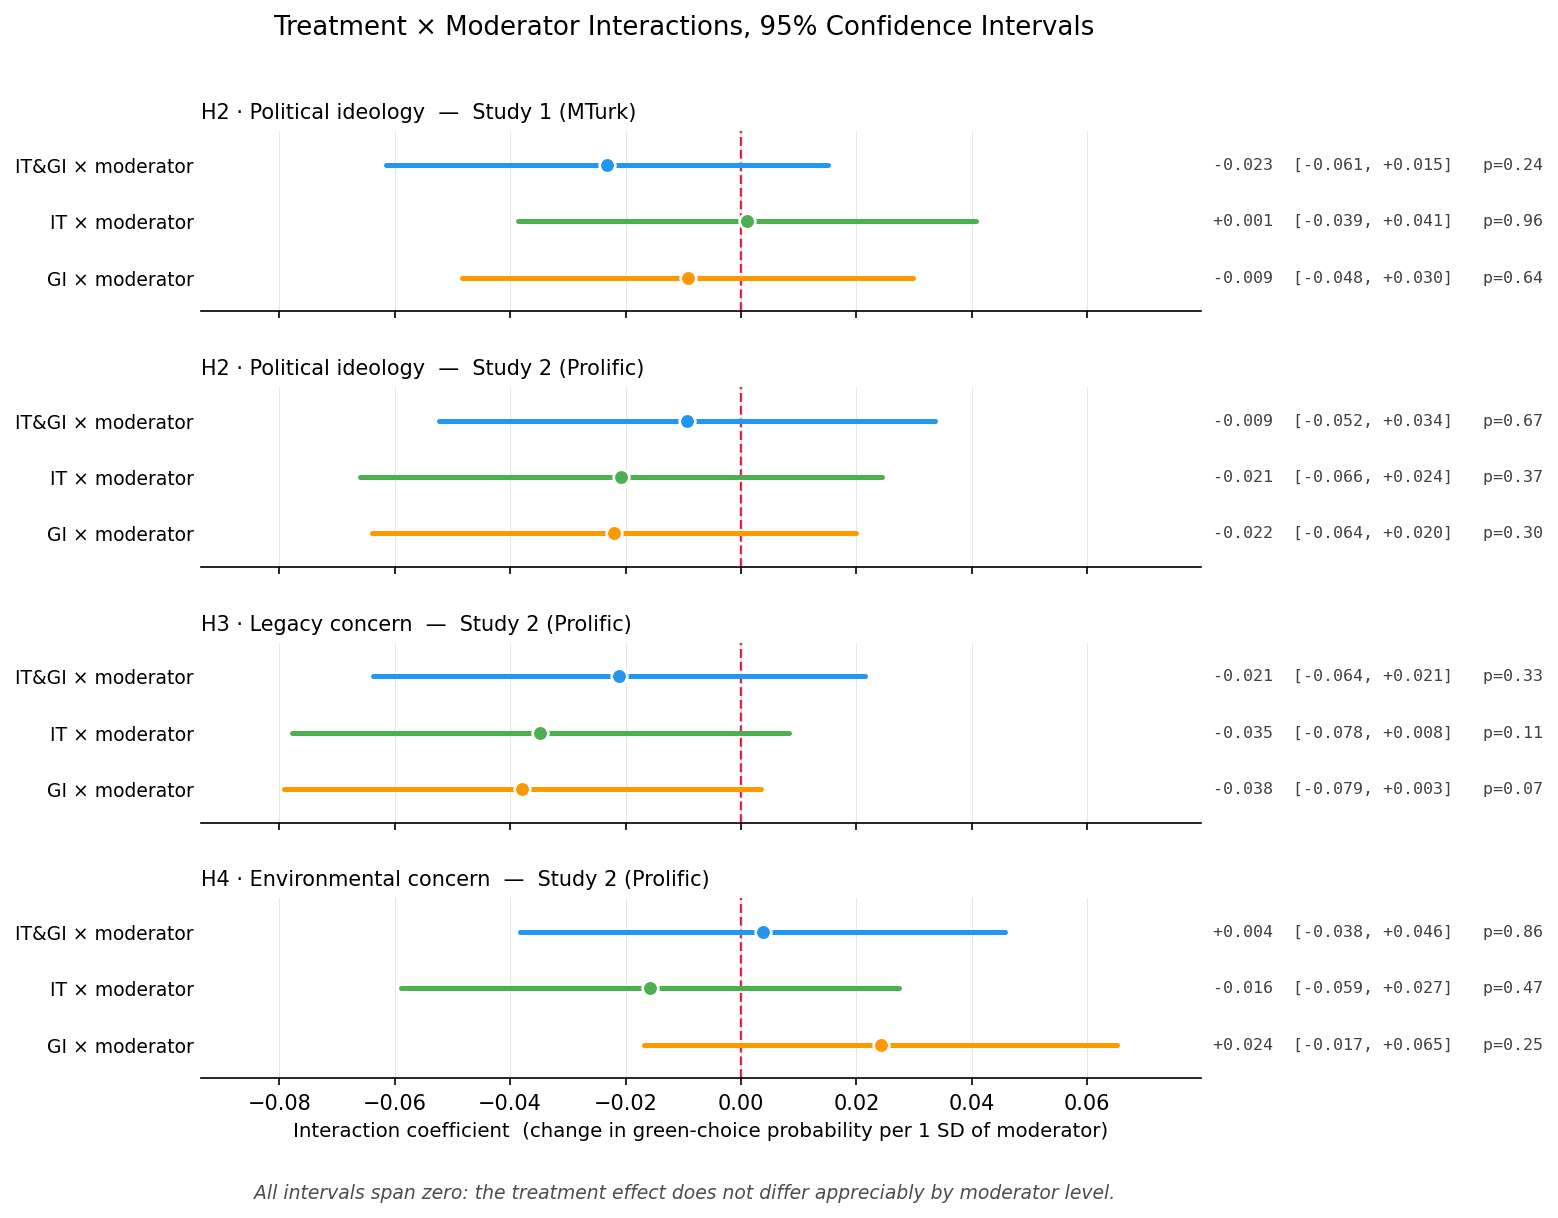

In [10]:
# Cell 9: Figure — forest plot of treatment × moderator interactions
CONTRASTS = [('[T.1]', 'IT&GI'), ('[T.2]', 'IT'), ('[T.3]', 'GI')]
PANELS = [
    ('H2 · Political ideology',      'Study 1 (MTurk)',    res_h2_mt, 'liberal_z'),
    ('H2 · Political ideology',      'Study 2 (Prolific)', res_h2_pr, 'liberal_z'),
    ('H3 · Legacy concern',          'Study 2 (Prolific)', res_h3_pr, 'legacy_z'),
    ('H4 · Environmental concern',   'Study 2 (Prolific)', res_h4_pr, 'env_concern_z'),
]

# Common x-range so panels are visually comparable.
lo_all, hi_all = 0.0, 0.0
for _, _, res, mod in PANELS:
    ci = res.conf_int()
    for tag, _ in CONTRASTS:
        t = f'C(treatment, Treatment(reference=4)){tag}:{mod}'
        lo_all = min(lo_all, ci.loc[t, 0]); hi_all = max(hi_all, ci.loc[t, 1])
pad = (hi_all - lo_all) * 0.10

fig, axes = plt.subplots(len(PANELS), 1, figsize=(8.6, 8.2), sharex=True,
                         gridspec_kw={'hspace': 0.42})

for ax, (hyp_label, study, res, mod) in zip(axes, PANELS):
    ci = res.conf_int()
    ylabels = []
    for i, (tag, tname) in enumerate(reversed(CONTRASTS)):
        t = f'C(treatment, Treatment(reference=4)){tag}:{mod}'
        b, lo, hi, p = res.params[t], ci.loc[t, 0], ci.loc[t, 1], res.pvalues[t]
        colour = TREAT_COLORS[tname]
        ax.plot([lo, hi], [i, i], color=colour, lw=2.4, solid_capstyle='round', zorder=2)
        ax.plot(b, i, 'o', color=colour, ms=7.5, mec='white', mew=1.3, zorder=3)
        ax.text(hi_all + pad * 1.15, i, f'{b:+.3f}  [{lo:+.3f}, {hi:+.3f}]   p={p:.2f}',
                va='center', fontsize=8, family='monospace', color='0.25')
        ylabels.append(f'{tname} \u00d7 moderator')
    ax.axvline(0, color='crimson', ls='--', lw=1.15, zorder=1)
    ax.set_yticks(range(len(CONTRASTS)))
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_ylim(-0.6, len(CONTRASTS) - 0.4)
    ax.set_xlim(lo_all - pad, hi_all + pad)
    ax.set_title(f'{hyp_label}  \u2014  {study}', fontsize=10, loc='left', pad=6)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', lw=0.4, alpha=0.35)

axes[-1].set_xlabel('Interaction coefficient  (change in green-choice probability per 1 SD of moderator)',
                    fontsize=9.5)
fig.suptitle('Treatment \u00d7 Moderator Interactions, 95% Confidence Intervals', fontsize=12.5, y=0.975)
fig.text(0.5, 0.012,
         'All intervals span zero: the treatment effect does not differ appreciably by moderator level.',
         ha='center', fontsize=9, style='italic', color='0.3')
plt.savefig('outputs/figures/fig_moderation_forest.png', dpi=200, bbox_inches='tight')
plt.show()

## 10 · Figure — Predicted Green Choice across the Moderator Range

The forest plot expresses the moderation tests as coefficients; the figure below expresses the same models on the scale of the outcome itself, which is more directly interpretable. Each panel plots the model-implied probability of green choice across the moderator's observed range, separately by treatment condition, with round held at its mean.

Moderation, had it been present, would appear as convergence or divergence between the lines: the treatment gap would widen or narrow across the moderator. Approximately parallel lines therefore constitute the visual signature of the null result, while the vertical separation between the treatment conditions and the control reproduces the main effects. Predictions derive from the fixed-effect estimates of the primary specifications, with intervals computed from the fixed-effect covariance matrix; random effects are held at their means, so the curves describe the average session and participant.

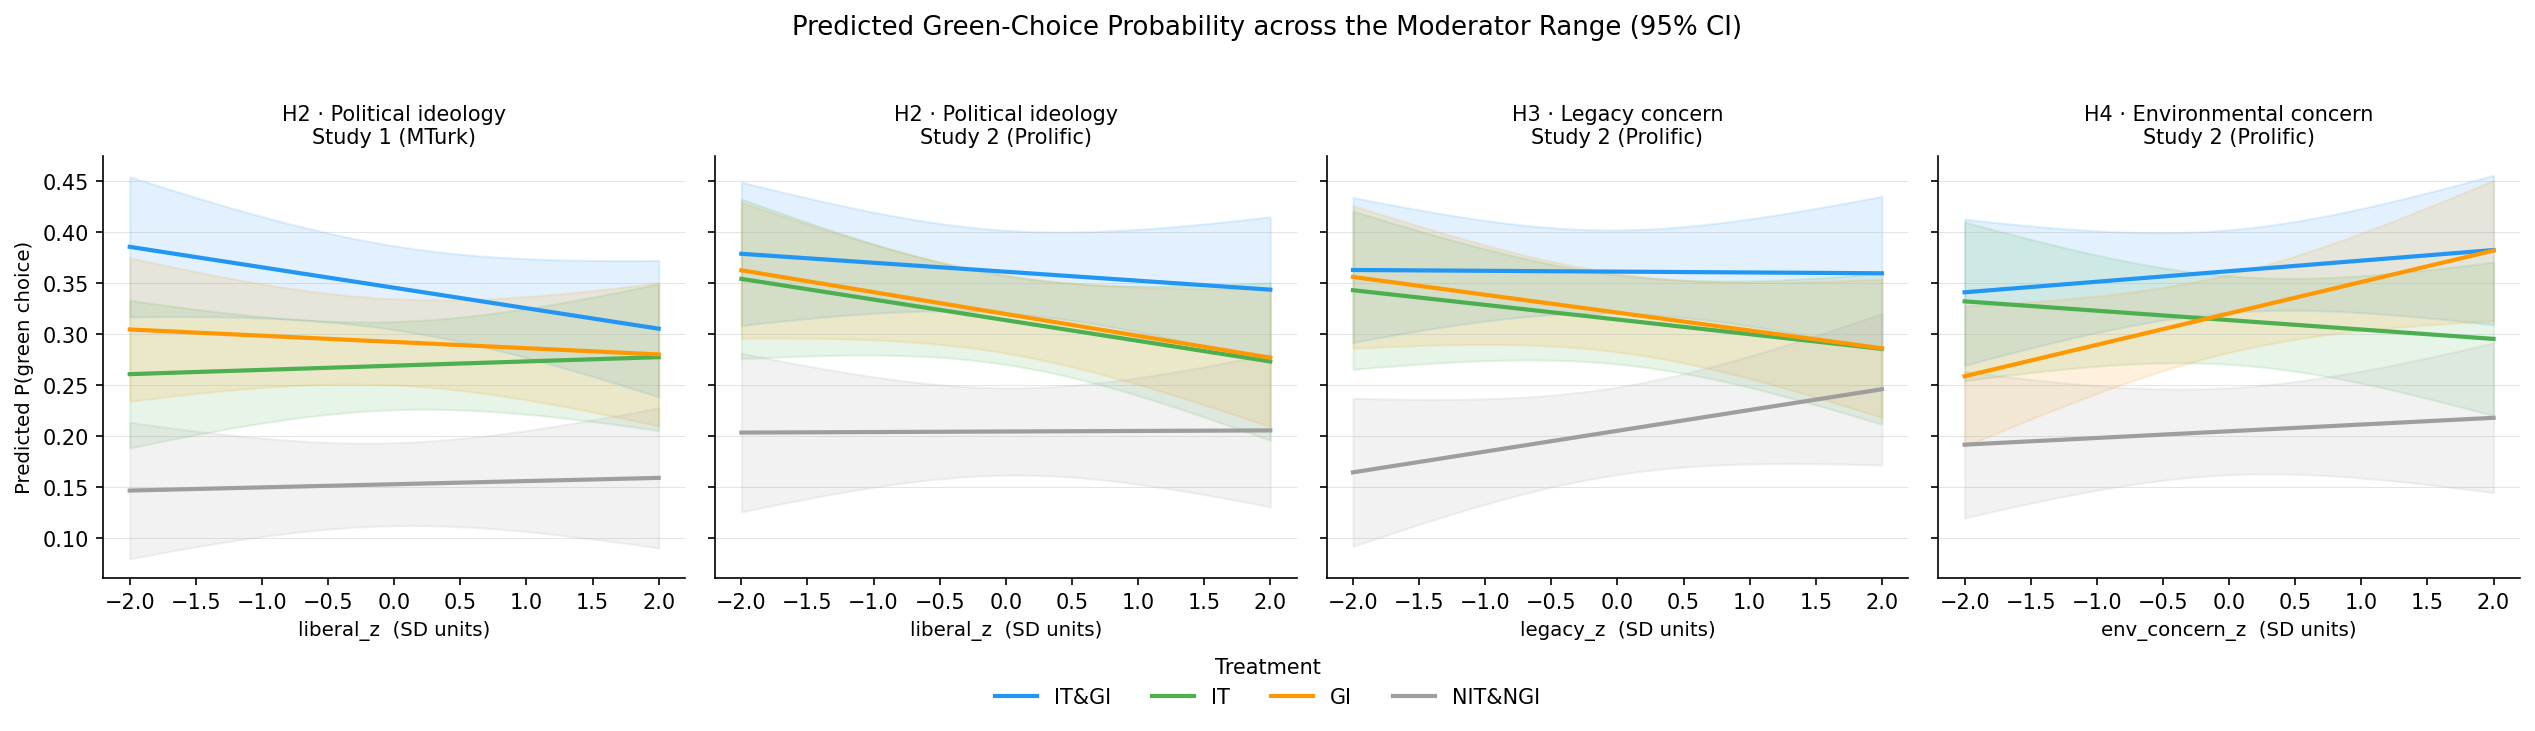

In [11]:
# Cell 10: Figure — predicted green-choice probability across the moderator range
import patsy

def predicted_curve(result, moderator, treat_level, grid):
    """Model-implied P(green) across a moderator grid at one treatment level.

    Evaluated at round_c = 0 (the mean round). Standard errors are taken from
    the fixed-effect block of the covariance matrix, so the band reflects
    uncertainty in the fixed effects with random effects at their means.
    """
    k_fe = result.model.k_fe
    V = np.asarray(result.cov_params())[:k_fe, :k_fe]
    beta = result.params.values[:k_fe]
    design_info = result.model.data.design_info
    newdata = pd.DataFrame({moderator: grid})
    newdata['treatment'] = treat_level
    newdata['round_c'] = 0.0
    X = patsy.build_design_matrices([design_info], newdata, return_type='dataframe')[0].values
    fitted = X @ beta
    se = np.sqrt(np.einsum('ij,jk,ik->i', X, V, X))
    return fitted, se

fig, axes = plt.subplots(1, len(PANELS), figsize=(17, 4.2), sharey=True)
grid = np.linspace(-2, 2, 60)

for ax, (hyp_label, study, res, mod) in zip(axes, PANELS):
    for lvl in [1, 2, 3, 4]:
        fitted, se = predicted_curve(res, mod, lvl, grid)
        colour = TREAT_COLORS[TREAT_MAP[lvl]]
        ax.plot(grid, fitted, color=colour, lw=2, label=TREAT_MAP[lvl])
        ax.fill_between(grid, fitted - 1.96 * se, fitted + 1.96 * se, color=colour, alpha=0.13)
    ax.set_title(f'{hyp_label}\n{study}', fontsize=10)
    ax.set_xlabel(f'{mod}  (SD units)', fontsize=9.5)
    ax.grid(axis='y', lw=0.4, alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Predicted P(green choice)', fontsize=9.5)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Treatment', loc='lower center', ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.10))
fig.suptitle('Predicted Green-Choice Probability across the Moderator Range (95% CI)',
             y=1.03, fontsize=12.5)
plt.tight_layout()
plt.savefig('outputs/figures/fig_moderation_predicted.png', dpi=200, bbox_inches='tight')
plt.show()

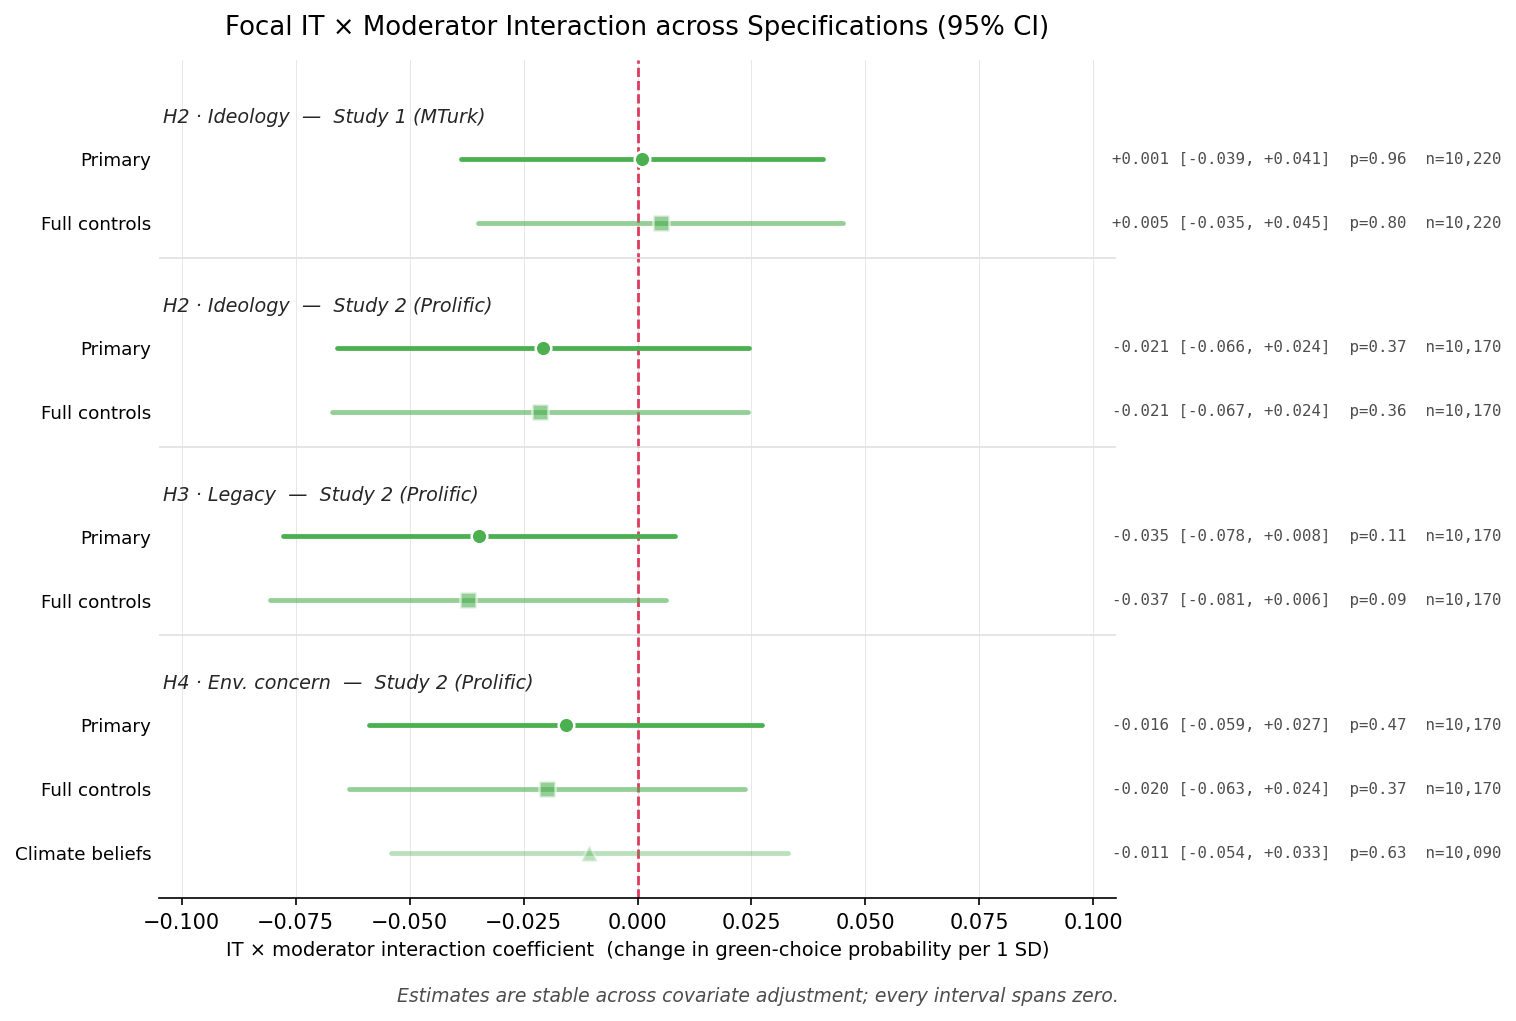

       hypothesis              study            spec     moderator    coef  ci_low  ci_high      p  n_obs
    H2 · Ideology    Study 1 (MTurk)         Primary     liberal_z  0.0011 -0.0387   0.0408 0.9586  10220
    H2 · Ideology    Study 1 (MTurk)   Full controls     liberal_z  0.0051 -0.0350   0.0451 0.8037  10220
    H2 · Ideology Study 2 (Prolific)         Primary     liberal_z -0.0208 -0.0660   0.0244 0.3678  10170
    H2 · Ideology Study 2 (Prolific)   Full controls     liberal_z -0.0214 -0.0670   0.0242 0.3572  10170
      H3 · Legacy Study 2 (Prolific)         Primary      legacy_z -0.0347 -0.0778   0.0083 0.1136  10170
      H3 · Legacy Study 2 (Prolific)   Full controls      legacy_z -0.0372 -0.0806   0.0062 0.0926  10170
H4 · Env. concern Study 2 (Prolific)         Primary env_concern_z -0.0158 -0.0589   0.0274 0.4735  10170
H4 · Env. concern Study 2 (Prolific)   Full controls env_concern_z -0.0198 -0.0632   0.0237 0.3722  10170
H4 · Env. concern Study 2 (Prolific) Climate b

In [12]:
# Cell 11: Figure — focal IT × moderator interaction across specifications
SPEC_ROWS = [
    ('H2 \u00b7 Ideology',     'Study 1 (MTurk)',    'Primary',         res_h2_mt,         'liberal_z'),
    ('H2 \u00b7 Ideology',     'Study 1 (MTurk)',    'Full controls',   res_h2_mt_robust,  'liberal_z'),
    ('H2 \u00b7 Ideology',     'Study 2 (Prolific)', 'Primary',         res_h2_pr,         'liberal_z'),
    ('H2 \u00b7 Ideology',     'Study 2 (Prolific)', 'Full controls',   res_h2_pr_robust,  'liberal_z'),
    ('H3 \u00b7 Legacy',       'Study 2 (Prolific)', 'Primary',         res_h3_pr,         'legacy_z'),
    ('H3 \u00b7 Legacy',       'Study 2 (Prolific)', 'Full controls',   res_h3_pr_robust,  'legacy_z'),
    ('H4 \u00b7 Env. concern', 'Study 2 (Prolific)', 'Primary',         res_h4_pr,         'env_concern_z'),
    ('H4 \u00b7 Env. concern', 'Study 2 (Prolific)', 'Full controls',   res_h4_pr_robust,  'env_concern_z'),
    ('H4 \u00b7 Env. concern', 'Study 2 (Prolific)', 'Climate beliefs', res_h4_pr_climate, 'env_concern_z'),
]
# Marker and opacity distinguish the specifications; the primary model is drawn solid.
SPEC_STYLE = {'Primary': ('o', 1.0), 'Full controls': ('s', 0.60), 'Climate beliefs': ('^', 0.38)}

# Extract the focal IT-only (T.2) interaction from each fitted specification.
spec_rows = []
for hyp, study, spec, result, moderator in SPEC_ROWS:
    term = f'C(treatment, Treatment(reference=4))[T.2]:{moderator}'
    ci = result.conf_int()
    spec_rows.append({
        'hypothesis': hyp, 'study': study, 'spec': spec, 'moderator': moderator,
        'coef': result.params[term], 'ci_low': ci.loc[term, 0], 'ci_high': ci.loc[term, 1],
        'p': result.pvalues[term], 'n_obs': int(result.nobs),
    })
spec_df = pd.DataFrame(spec_rows)
spec_df.round(4).to_csv('outputs/tables/h2_h4_focal_across_specifications.csv', index=False)

groups = list(dict.fromkeys(zip(spec_df['hypothesis'], spec_df['study'])))
fig, ax = plt.subplots(figsize=(10.2, 6.6))
y, ypos, ylabels, boundaries = 0.0, [], [], []

for gi, (hyp, study) in enumerate(reversed(groups)):
    block = spec_df[(spec_df['hypothesis'] == hyp) & (spec_df['study'] == study)]
    for r in block[::-1].itertuples():
        marker, alpha = SPEC_STYLE[r.spec]
        ax.plot([r.ci_low, r.ci_high], [y, y], color=TREAT_COLORS['IT'], lw=2.3,
                alpha=alpha, solid_capstyle='round', zorder=2)
        ax.plot(r.coef, y, marker, color=TREAT_COLORS['IT'], ms=7.5, alpha=alpha,
                mec='white', mew=1.2, zorder=3)
        ax.text(0.104, y,
                f'{r.coef:+.3f} [{r.ci_low:+.3f}, {r.ci_high:+.3f}]  p={r.p:.2f}  n={r.n_obs:,}',
                va='center', fontsize=7.6, family='monospace', color='0.3')
        ypos.append(y); ylabels.append(r.spec); y += 1
    ax.text(-0.104, y - 0.35, f'{hyp}  \u2014  {study}', fontsize=9.2, style='italic',
            color='0.15', va='center', ha='left')
    y += 0.95
    if gi < len(groups) - 1:
        boundaries.append(y - 0.55)

ax.axvline(0, color='crimson', ls='--', lw=1.2, zorder=1)
for b in boundaries:
    ax.axhline(b, color='0.88', lw=0.8)
ax.set_yticks(ypos); ax.set_yticklabels(ylabels, fontsize=8.8)
ax.set_xlim(-0.105, 0.105); ax.set_ylim(-0.7, y - 0.4)
ax.set_xlabel('IT \u00d7 moderator interaction coefficient  '
              '(change in green-choice probability per 1 SD)', fontsize=9.3)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.grid(axis='x', lw=0.4, alpha=0.35)
ax.set_title('Focal IT \u00d7 Moderator Interaction across Specifications (95% CI)',
             fontsize=12.5, pad=12)
fig.text(0.5, -0.02,
         'Estimates are stable across covariate adjustment; every interval spans zero.',
         ha='center', fontsize=9, style='italic', color='0.3')
plt.tight_layout()
plt.savefig('outputs/figures/fig_focal_across_specifications.png', dpi=200, bbox_inches='tight')
plt.show()

print(spec_df.round(4).to_string(index=False))